In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("/kaggle/input/datasets/sriharshaeedala/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv")

display(df.head())
display(df.tail())

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/sriharshaeedala/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv'

: 

Questions to answer:
- What does one row represent?
- What is the target column?
- Which columns are numerical, categorical, or identifiers?
- How large is the dataset?

In [ ]:
# Missing values
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
}).sort_values("missing_percentage", ascending=False)

display(missing)

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Data types
display(df.dtypes.rename("data_type").to_frame())

# Unique values
display(df.nunique().sort_values(ascending=False))

# Numerical statistics
display(df.describe().T)

,missing_count,missing_percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


Duplicate rows: 0


,data_type
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


nameOrig          6353307
amount            5316900
oldbalanceDest    3614697
newbalanceDest    3555499
nameDest          2722362
newbalanceOrig    2682586
oldbalanceOrg     1845844
step                  743
type                    5
isFraud                 2
isFlaggedFraud          2
dtype: int64

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [ ]:
print(df["isFraud"].value_counts())

print("\nPercentage distribution:")
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentage distribution:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


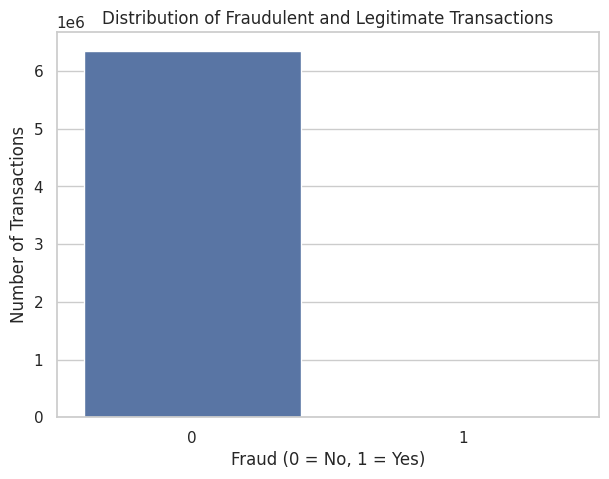

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="isFraud")

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="amount", bins=50, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")

sns.boxplot(data=df, x="amount", ax=axes[1])
axes[1].set_title("Transaction Amount Outliers")

plt.tight_layout()
plt.show()

In [ ]:
sns.histplot(
    x=np.log1p(df["amount"].clip(lower=0)),
    bins=50
)
plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(1 + amount)")
plt.show()

Step 5 — Bivariate analysis: compare features with fraud
This is where your EDA becomes specifically useful for the fraud-detection problem.
A. Fraud rate by transaction type

In [ ]:
fraud_rate = (
    df.groupby("type")["isFraud"]
      .agg(["mean", "count", "sum"])
      .rename(columns={
          "mean": "fraud_rate",
          "count": "total_transactions",
          "sum": "fraud_count"
      })
      .sort_values("fraud_rate", ascending=False)
)

display(fraud_rate)

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="type",
    y="isFraud",
    errorbar=None
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount (log scale)")
plt.show()

In [ ]:
df["orig_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["balance_error_orig"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

display(
    df.groupby("isFraud")[
        ["amount", "orig_balance_change", "balance_error_orig"]
    ].median()
)

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 9))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Step 7 — Investigate suspicious patterns
This section can make your notebook more interesting than a standard EDA.
Explore questions such as:
- Are fraud cases concentrated in certain transaction types?
- Do fraudulent transactions have different amounts from legitimate ones?
- Are sender balance changes inconsistent with transaction amounts?
- Are there duplicate transactions or unusual repeated account patterns?
- If a time or step column exists, does the fraud rate change over time?
- If a flagged-fraud column exists, how often does it agree with the actual fraud label?

In [ ]:
display(
    pd.crosstab(
        df["isFraud"],
        df["isFlaggedFraud"],
        normalize="index"
    ) * 100
)

In [ ]:
sample_df = df.sample(
    n=min(200_000, len(df)),
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=sample_df, x="type", ax=axes[0])
axes[0].set_title("Transaction Type Distribution")

sns.histplot(
    data=sample_df,
    x="amount",
    bins=60,
    ax=axes[1]
)
axes[1].set_title("Transaction Amount Distribution")

plt.tight_layout()
plt.show()

In [ ]:
fraud_counts = df["isFraud"].value_counts().sort_index()

display(fraud_counts.rename("Transaction Count").to_frame())

fraud_percentages = (
    df["isFraud"].value_counts(normalize=True).sort_index() * 100
)

display(fraud_percentages.rename("Percentage").to_frame())

In [ ]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

display(
    df.groupby("isFraud")["orig_balance_error"]
      .agg(["mean", "median", "min", "max"])
)

In [ ]:
sns.boxplot(
    data=df.sample(200_000, random_state=42),
    x="isFraud",
    y="orig_balance_error"
)

plt.ylim(-1_000_000, 1_000_000)
plt.title("Sender Balance Error by Fraud Status")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Balance Error")
plt.show()

Finding:  The plot shows that legitimate transactions have widely spread negative balance errors, while most fraudulent transactions have errors close to zero. This feature looks potentially useful.


In [ ]:
step_analysis = (
    df.groupby("step")["isFraud"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_transactions",
          "sum": "fraud_count",
          "mean": "fraud_rate"
      })
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    step_analysis.index,
    step_analysis["total_transactions"]
)
ax1.set_xlabel("Step")
ax1.set_ylabel("Total Transactions")

plt.title("Transaction Volume Over Time")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    step_analysis.index,
    step_analysis["fraud_rate"] * 100
)
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Over Time")
plt.show()

In [ ]:
display(
    step_analysis.sort_values(
        "fraud_count", ascending=False
    ).head(10)
)

In [ ]:
df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

display(
    df.groupby("isFraud")["dest_balance_error"]
      .agg(["mean", "median", "min", "max"])
)

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fraud_rate.reset_index(),
    x="type",
    y="fraud_count"
)

plt.title("Fraud Count by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(rotation=30)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df.sample(200_000, random_state=42),
    x="type",
    y="amount",
    hue="isFraud",
    showfliers=False
)

plt.yscale("log")
plt.title("Transaction Amount by Type and Fraud Status")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount (log scale)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
display(
    df[df["isFraud"] == 1]
    .groupby("nameOrig")
    .size()
    .value_counts()
    .sort_index()
    .rename("Number of Senders")
    .to_frame()
)

display(
    df[df["isFraud"] == 1]
    .groupby("nameDest")
    .size()
    .value_counts()
    .sort_index()
    .rename("Number of Recipients")
    .to_frame()
)

In [ ]:
pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    rownames=["Actual Fraud"],
    colnames=["Flagged Fraud"]
)

- The dataset contains 6,362,620 transactions and has no missing values or duplicate rows.



- Fraudulent transactions account for approximately 0.129% of all transactions.



- TRANSFER has a higher fraud rate, while CASH_OUT has a slightly higher fraud count.



- Fraudulent transactions have a higher median transaction amount than legitimate transactions.



- The existing isFlaggedFraud flag catches only 16 fraudulent transactions.